# Mapping Singapore's eldercare network

**Healthcare: Visualised**

Singapore is ageing faster than almost anywhere on earth: by 2030, around one in four
citizens will be 65 or older. That shift is quietly reshaping the country's care
infrastructure — the drop-in centres, day-care hubs, and residential homes that support older
people close to where they live.

This notebook takes an open dataset of **133 eldercare facilities** from
[data.gov.sg](https://data.gov.sg/) and asks three structural questions: **what** kinds of
care exist, **who** provides them, and **where** they sit across the island.

The raw file is a KML-derived GeoJSON: each facility is a map point whose useful attributes
are buried in an HTML table inside a `Description` field. Step one is turning that mess into a
clean table.

In [1]:
import json, re
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# One cohesive palette for the whole piece
INK   = "#264653"   # text + primary
TEAL  = "#2A9D8F"
CORAL = "#E76F51"
GOLD  = "#E9C46A"
PLUM  = "#6D597A"
BLUE  = "#457B9D"
MUTE  = "#c7ccce"   # recede

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "figure.dpi": 120,
    "text.color": INK, "axes.labelcolor": INK,
})

def style_axes(ax, grid_axis=None):
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    ax.spines["left"].set_color("#d9d9d9")
    ax.spines["bottom"].set_color("#d9d9d9")
    ax.tick_params(length=0, colors="#666", labelsize=9)
    if grid_axis:
        ax.grid(axis=grid_axis, color="#ededed", lw=1)
    ax.set_axisbelow(True)

def titles(fig, ax, title, subtitle):
    fig.suptitle(title, x=0.02, y=1.0, ha="left", fontsize=15,
                 fontweight="bold", color=INK)
    ax.set_title(subtitle, loc="left", fontsize=10.5, color="#666", pad=10)

def save(fig, name, source="Source: Eldercare Services, data.gov.sg"):
    fig.text(0.02, 0.0, source, fontsize=8, color="#9a9a9a", ha="left")
    fig.tight_layout(rect=[0, 0.04, 1, 0.92])
    fig.savefig(name, dpi=200, bbox_inches="tight", facecolor="white")

# consistent colour per service type, reused across every chart
type_colors = {
    "Senior Activity Centre": TEAL,
    "Residential Home":       CORAL,
    "Senior Group Home":      PLUM,
    "Cluster Support":        GOLD,
    "Care / Wellness Centre": BLUE,
    "Other / Operator HQ":    MUTE,
}

## 1. Parse the GeoJSON into a tidy table

Each feature's `Description` holds an HTML `<table>`. We pull every `<th>label</th><td>value</td>`
pair, then keep name, address, postal code, and coordinates.

In [2]:
with open("eldercare-services.geojson") as f:
    gj = json.load(f)

def parse_attrs(desc):
    pairs = re.findall(r"<th>(.*?)</th>\s*<td>(.*?)</td>", desc)
    return {k: v.strip() for k, v in pairs}

rows = []
for feat in gj["features"]:
    a = parse_attrs(feat["properties"]["Description"])
    lon, lat = feat["geometry"]["coordinates"][:2]
    rows.append({
        "name":   a.get("NAME", "").strip(),
        "street": a.get("ADDRESSSTREETNAME", "").strip(),
        "postal": a.get("ADDRESSPOSTALCODE", "").strip(),
        "lat": lat, "lon": lon,
    })

df = pd.DataFrame(rows)
df["sector"] = df["postal"].str[:2]
print(f"{len(df)} facilities parsed")
df.head()

133 facilities parsed


,name,street,postal,lat,lon,sector
0,Yuhua Senior Activity Centre,318A Jurong East Avenue 1 #02-308,601318,1.347624,103.731009,60
1,THK SAC @ Kaki Bukit,Blk 509B Bedok North Street 3 #02-157,462509,1.333693,103.930397,46
2,THK SAC @ Boon Lay,Blk 190 Boon Lay Drive #01-242,640190,1.345077,103.711850,64
3,PEACE-Connect Senior Activity Centre@5,5 Beach Rd #02-4943,190005,1.304346,103.864816,19
4,THK SAC @ Beo Crescent,Blk 44 Beo Crescent #01-67,160044,1.288809,103.826295,16


## 2. Classify service type, operator, and region

Facility names encode three useful dimensions. We tag each with keyword rules, and infer a
broad region from the postal sector (first two digits). These are *inferred* — good enough for
structural insight, but not an authoritative registry (see the closing caveats).

In [3]:
def service_type(name):
    n = name.lower()
    if any(k in n for k in ["home for the", "home @", "golden age", "happy villa",
                            "st vincent", "welfare home", "citizens' home", "senior citizens"]):
        return "Residential Home"
    if "senior group home" in n or "sgh" in n:
        return "Senior Group Home"
    if "cluster support" in n or "cluster operator" in n or "cluster suppport" in n:
        return "Cluster Support"
    if any(k in n for k in ["senior activity", "sac", "silver ace", "goodlife",
                            "befriend", "activity centre"]):
        return "Senior Activity Centre"
    if any(k in n for k in ["wellness", "care centre", "day care", "daycare", "eldercare"]):
        return "Care / Wellness Centre"
    return "Other / Operator HQ"

def operator(name):
    n = name.lower()
    table = [("thk", "THK / Thye Hua Kwan"), ("thye hua kwan", "THK / Thye Hua Kwan"),
             ("lions befriend", "Lions Befrienders"), ("care corner", "Care Corner"),
             ("carecorner", "Care Corner"), ("peace-connect", "PEACE-Connect"),
             ("peace connect", "PEACE-Connect"), ("fei yue", "Fei Yue"),
             ("silver ace", "Silver ACE"), ("touch", "TOUCH"), ("ntuc", "NTUC Health"),
             ("presbyterian", "Presbyterian CS"), ("anglican", "Anglican CS"),
             ("methodist", "Methodist WS"), ("econ", "Econ Healthcare"),
             ("adventist", "Adventist"), ("amkfsc", "AMKFSC"), ("comnet", "COMNET"),
             ("goodlife", "GoodLife"), ("indus moral", "Indus Moral"),
             ("pertapis", "PERTAPIS"), ("sbws", "SBWS"), ("awwa", "AWWA")]
    for key, label in table:
        if key in n:
            return label
    return "Other / Independent"

# Postal sector (first 2 digits) -> broad region. Approximate; validated to cover every
# sector present in this dataset.
SECTOR_REGION = {
    "05": "Central", "08": "Central", "09": "Central", "10": "Central", "12": "Central",
    "14": "Central", "15": "Central", "31": "Central", "32": "Central", "33": "Central",
    "34": "Central", "37": "Central", "38": "Central", "40": "Central", "57": "Central",
    "16": "East", "18": "East", "44": "East", "46": "East", "52": "East",
    "19": "North-East", "20": "North-East", "53": "North-East", "54": "North-East",
    "56": "North-East", "79": "North-East", "82": "North-East",
    "27": "North", "73": "North", "76": "North",
    "21": "West", "22": "West", "59": "West", "60": "West", "61": "West",
    "64": "West", "65": "West", "68": "West",
}

df["service_type"] = df["name"].map(service_type)
df["operator"]     = df["name"].map(operator)
df["region"]       = df["sector"].map(SECTOR_REGION).fillna("Unclassified")

df[["name", "service_type", "operator", "region"]].head(8)

,name,service_type,operator,region
0,Yuhua Senior Activity Centre,Senior Activity Centre,Other / Independent,West
1,THK SAC @ Kaki Bukit,Senior Activity Centre,THK / Thye Hua Kwan,East
2,THK SAC @ Boon Lay,Senior Activity Centre,THK / Thye Hua Kwan,West
3,PEACE-Connect Senior Activity Centre@5,Senior Activity Centre,PEACE-Connect,North-East
4,THK SAC @ Beo Crescent,Senior Activity Centre,THK / Thye Hua Kwan,East
5,Silver ACE @ Bukit Merah,Senior Activity Centre,Silver ACE,East
6,Lions Befrienders Senior Activity Centre @ Tam...,Senior Activity Centre,Lions Befrienders,East
7,Care Corner Senior Activity Centre (WL569),Senior Activity Centre,Care Corner,North


## 3. The dataset at a glance

In [4]:
print("Total facilities   :", len(df))
print("Service types      :", df.service_type.nunique())
print("Regions covered    :", df.region.nunique(), "(Unclassified:",
      int((df.region == "Unclassified").sum()), ")")
print("Named operators    :", int((df.operator != "Other / Independent").sum()), "of", len(df))
print("\nService-type breakdown:")
print(df.service_type.value_counts().to_string())

Total facilities   : 133
Service types      : 6
Regions covered    : 5 (Unclassified: 0 )
Named operators    : 87 of 133

Service-type breakdown:
service_type
Senior Activity Centre    76
Residential Home          25
Other / Operator HQ        9
Cluster Support            9
Care / Wellness Centre     9
Senior Group Home          5


## 4. Where are they?

A static map of all 133 points, coloured by service type. Even without a basemap, the shape of
Singapore's populated core emerges — and residential homes visibly sit apart from the dense
mesh of neighbourhood Senior Activity Centres.

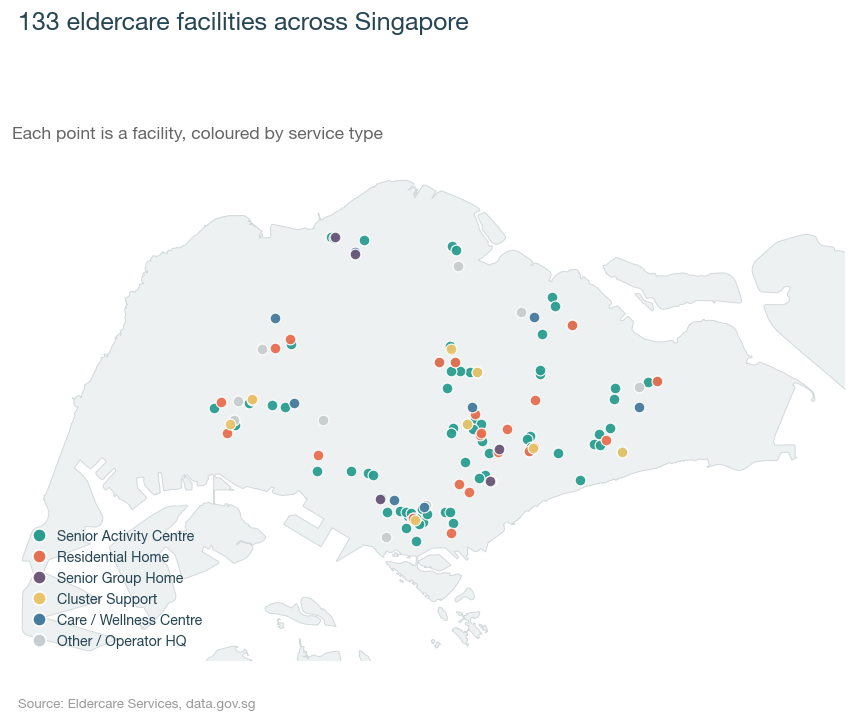

In [5]:
# light Singapore outline as a basemap
outline = json.load(open("sg-outline.geojson"))
fig, ax = plt.subplots(figsize=(10, 5.8))
for feat in outline["features"]:
    for poly in feat["geometry"]["coordinates"]:
        ring = poly[0]
        ax.fill([p[0] for p in ring], [p[1] for p in ring],
                facecolor="#eef1f2", edgecolor="#d3d9db", linewidth=0.6, zorder=0)

order = df.service_type.value_counts().index  # draw common types first
for t in order:
    d = df[df.service_type == t]
    ax.scatter(d.lon, d.lat, s=42, color=type_colors[t], edgecolor="white",
               linewidth=0.7, alpha=0.95, label=t, zorder=3)

ax.set_aspect("equal")
ax.set_xlim(103.60, 104.06)
ax.set_ylim(1.205, 1.485)
ax.set_anchor("W")   # hug the left so the box aligns under the left title
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)

handles = [Line2D([0], [0], marker="o", linestyle="", markersize=8,
                  markerfacecolor=type_colors[t], markeredgecolor="white",
                  label=t) for t in type_colors if t in set(df.service_type)]
ax.legend(handles=handles, loc="lower left", fontsize=8.5, frameon=False,
          handletextpad=0.3, labelspacing=0.5)

fig.suptitle("133 eldercare facilities across Singapore", x=0.02, y=1.0, ha="left",
             fontsize=15, fontweight="bold", color=INK)
ax.set_title("Each point is a facility, coloured by service type", loc="left",
             fontsize=10.5, color="#666", pad=10)
save(fig, "eldercare-map.png")
plt.show()

## 5. What kind of care?

The network is overwhelmingly **Senior Activity Centres** — neighbourhood drop-in and
befriending hubs in the HDB heartlands — atop a smaller residential tier and a still-small
Senior Group Home model for supported communal living.

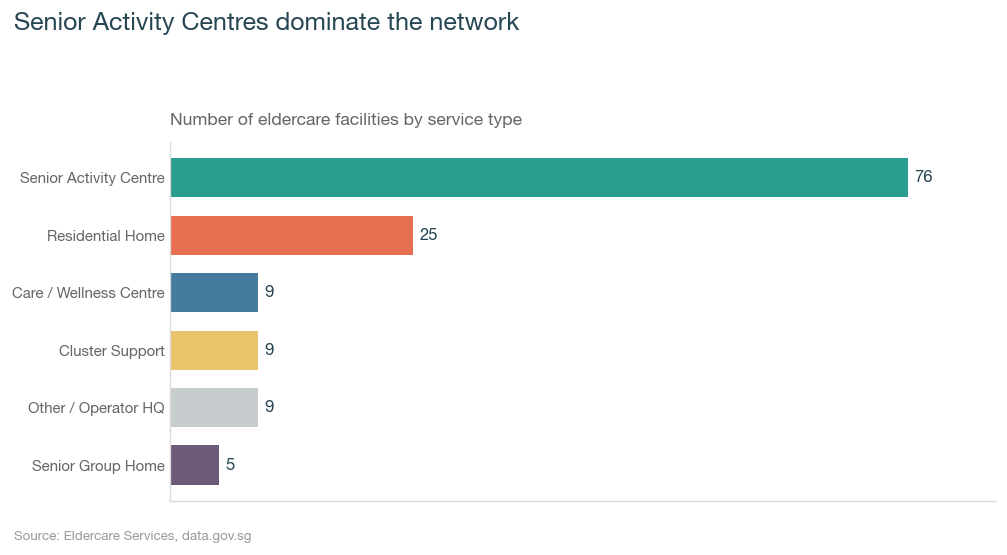

In [6]:
vc = df.service_type.value_counts().sort_values()
fig, ax = plt.subplots(figsize=(8.5, 4.4))
ax.barh(vc.index, vc.values, color=[type_colors[t] for t in vc.index], height=0.68)
for i, v in enumerate(vc.values):
    ax.text(v + 0.7, i, str(v), va="center", ha="left", fontsize=10,
            fontweight="bold", color=INK)
ax.set_xlim(0, vc.max() * 1.12)
style_axes(ax)
ax.set_xticks([])
titles(fig, ax, "Senior Activity Centres dominate the network",
       "Number of eldercare facilities by service type")
save(fig, "eldercare-service-mix.png")
plt.show()

## 6. Who runs them?

Provision leans on a handful of Voluntary Welfare Organisations. THK (Thye Hua Kwan) is the
single largest named operator, followed by Lions Befrienders and Care Corner. (Facilities whose
name carries no operator are left out here.)

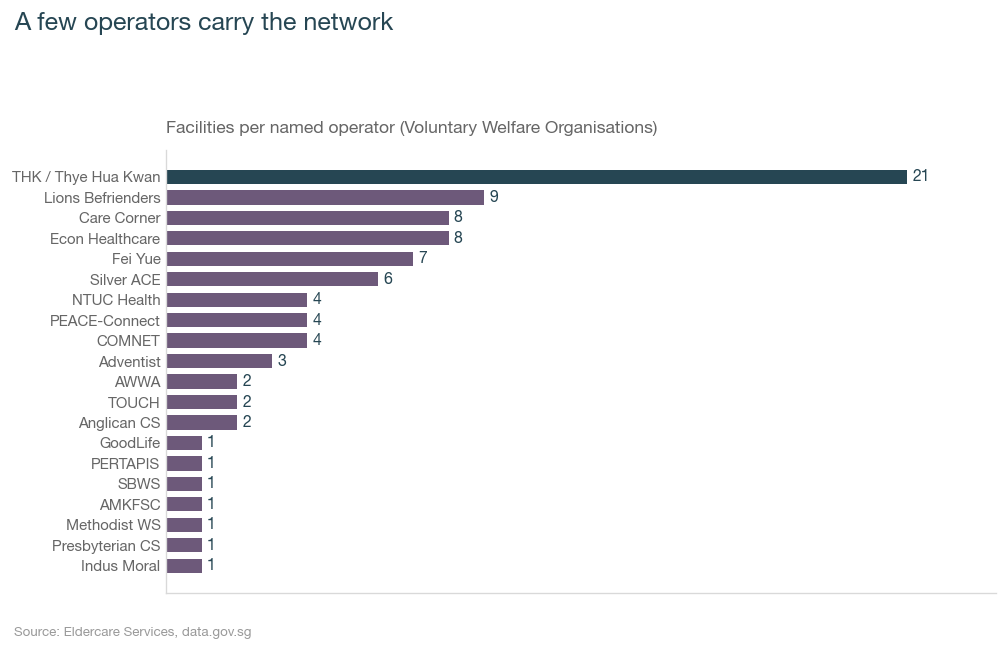

In [7]:
op = df[df.operator != "Other / Independent"].operator.value_counts().sort_values()
fig, ax = plt.subplots(figsize=(8.5, 5.2))
colors = [INK if v == op.max() else PLUM for v in op.values]
ax.barh(op.index, op.values, color=colors, height=0.7)
for i, v in enumerate(op.values):
    ax.text(v + 0.15, i, str(v), va="center", ha="left", fontsize=9.5,
            fontweight="bold", color=INK)
ax.set_xlim(0, op.max() * 1.12)
style_axes(ax)
ax.set_xticks([])
titles(fig, ax, "A few operators carry the network",
       "Facilities per named operator (Voluntary Welfare Organisations)")
save(fig, "eldercare-operators.png")
plt.show()

## 7. How does provision split across regions?

Grouping by inferred region shows both the load per region and its service mix. The Central belt
and the East lead — the older, denser estates — while the North looks comparatively thin.

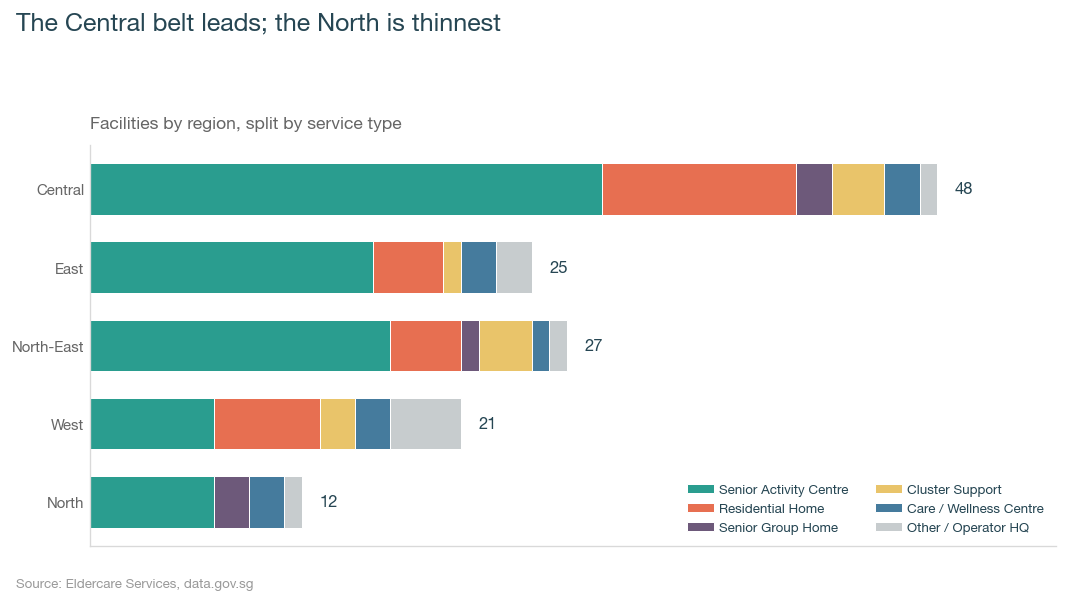

In [8]:
reg_order = ["Central", "East", "North-East", "West", "North"]
comp = (df.pivot_table(index="region", columns="service_type", aggfunc="size", fill_value=0)
          .reindex(reg_order))
comp = comp[[t for t in type_colors if t in comp.columns]]  # consistent colour order

fig, ax = plt.subplots(figsize=(9, 4.8))
left = pd.Series(0, index=comp.index)
for t in comp.columns:
    ax.barh(comp.index, comp[t], left=left, color=type_colors[t], height=0.66,
            edgecolor="white", linewidth=0.6, label=t)
    left += comp[t]
totals = comp.sum(axis=1)
for i, v in enumerate(totals):
    ax.text(v + 1, i, str(int(v)), va="center", ha="left", fontsize=10,
            fontweight="bold", color=INK)
ax.invert_yaxis()
ax.set_xlim(0, totals.max() * 1.14)
style_axes(ax)
ax.set_xticks([])
ax.legend(fontsize=8, frameon=False, ncol=2, loc="lower right", handletextpad=0.4)
titles(fig, ax, "The Central belt leads; the North is thinnest",
       "Facilities by region, split by service type")
save(fig, "eldercare-region.png")
plt.show()

## 8. The hotspot sectors

Zooming to postal sectors, the densest are Ang Mo Kio / Bishan, Katong / Marine Parade, and Toa
Payoh — mature towns whose resident populations are among the oldest in Singapore.

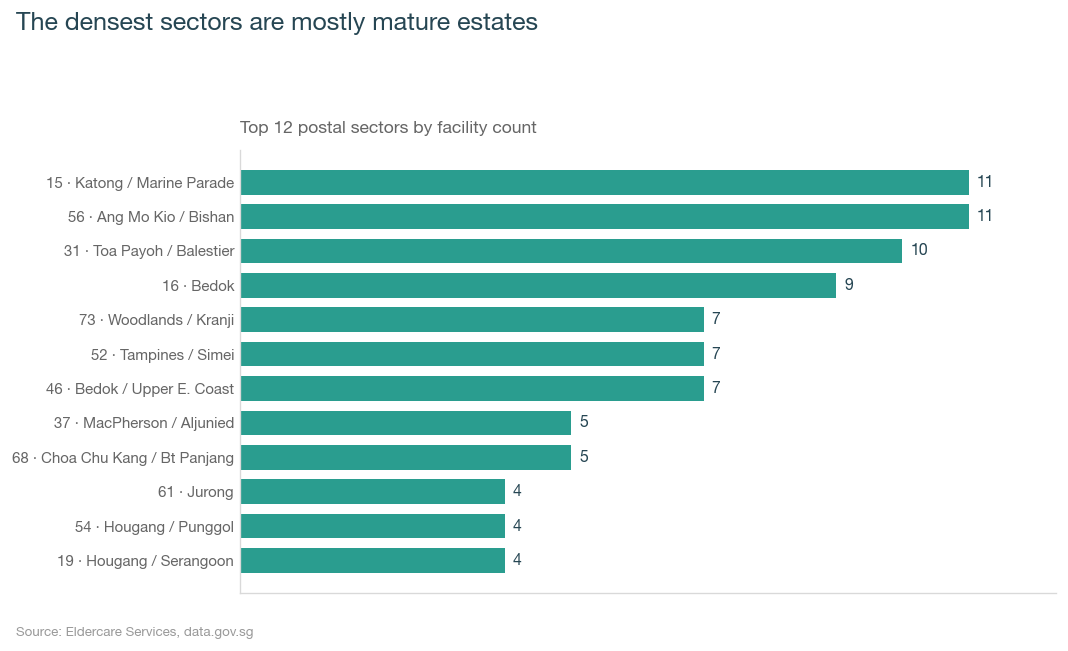

In [9]:
SECTOR_NAME = {
    "56": "Ang Mo Kio / Bishan", "15": "Katong / Marine Parade", "31": "Toa Payoh / Balestier",
    "16": "Bedok", "46": "Bedok / Upper E. Coast", "52": "Tampines / Simei",
    "73": "Woodlands / Kranji", "68": "Choa Chu Kang / Bt Panjang", "37": "MacPherson / Aljunied",
    "19": "Hougang / Serangoon", "54": "Hougang / Punggol", "61": "Jurong",
    "33": "MacPherson / Braddell", "14": "Geylang / Eunos",
}
top = df.sector.value_counts().head(12).sort_values()
labels = [f"{s} · {SECTOR_NAME.get(s, 'other')}" for s in top.index]

fig, ax = plt.subplots(figsize=(9, 5.2))
ax.barh(labels, top.values, color=TEAL, height=0.72)
for i, v in enumerate(top.values):
    ax.text(v + 0.12, i, str(v), va="center", ha="left", fontsize=9.5,
            fontweight="bold", color=INK)
ax.set_xlim(0, top.max() * 1.12)
style_axes(ax)
ax.set_xticks([])
titles(fig, ax, "The densest sectors are mostly mature estates",
       "Top 12 postal sectors by facility count")
save(fig, "eldercare-hotspots.png")
plt.show()

## What the data hides

These charts describe *supply*. They cannot, on their own, tell us about **access** — and that
gap matters most.

- **Counts are not need.** A region with few facilities may simply have few older residents. To
  judge adequacy you would divide facilities by the elderly population of each area — data this
  file does not carry.
- **Type, operator, and region are inferred** from names and postal codes, not an official
  registry. A handful of edge cases will be mislabelled.
- **This is one snapshot.** It shows where the network *is*, not how fast it is growing toward a
  population that, by 2030, will be one-quarter aged 65+.

Supply is the easy half to map. Whether it matches need is the harder, more important question —
and the natural next dataset.